In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## Review: Comparing Two Samples

In [2]:
def difference_of_means(table, numeric_label, group_label):
    """
    Takes: name of table, column label of numerical variable,
    column label of group-label variable
    
    Returns: Difference of means of the two groups
    """
    
    #table with the two relevant columns
    reduced = table.select(numeric_label, group_label)  
    
    # table containing group means
    means_table = reduced.group(group_label, np.average)
    
    # array of group means
    means = means_table.column(1)
    
    return means.item(1) - means.item(0)

In [3]:
def one_simulated_difference(table, numeric_label, group_label):
    """
    Takes: name of table, column label of numerical variable,
    column label of group-label variable
    
    Returns: Difference of means of the two groups after shuffling labels
    """
    
    # array of shuffled labels
    shuffled_labels = table.sample(
        with_replacement = False).column(group_label)
    
    # table of numerical variable and shuffled labels
    shuffled_table = table.select(numeric_label).with_column(
        'Shuffled Label', shuffled_labels)
    
    return difference_of_means(
        shuffled_table, numeric_label, 'Shuffled Label')   

In [4]:
births = Table.read_table('baby.csv')

In [5]:
births.group('Maternal Smoker', np.average)

Maternal Smoker,Birth Weight average,Gestational Days average,Maternal Age average,Maternal Height average,Maternal Pregnancy Weight average
False,123.085,279.874,27.5441,64.014,129.48
True,113.819,277.898,26.7364,64.1046,126.919


# Randomized Control Experiment

In [6]:
botox = Table.read_table('bta.csv')
botox.show()

Group,Result
Control,1
Control,1
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0


In [7]:
botox.pivot('Result', 'Group')

Group,0.0,1.0
Control,14,2
Treatment,6,9


In [8]:
botox.group('Group', np.average)

Group,Result average
Control,0.125
Treatment,0.6


# Testing the Hypothesis

In [9]:
observed_diff = difference_of_means(botox, 'Result', 'Group')
observed_diff

0.475

In [10]:
one_simulated_difference(botox, 'Result', 'Group')

-0.17083333333333334

In [18]:
simulated_diffs = make_array()

for i in np.arange(10000):
    sim_diff = one_simulated_difference(botox, 'Result', 'Group')
    simulated_diffs = np.append(simulated_diffs, sim_diff)

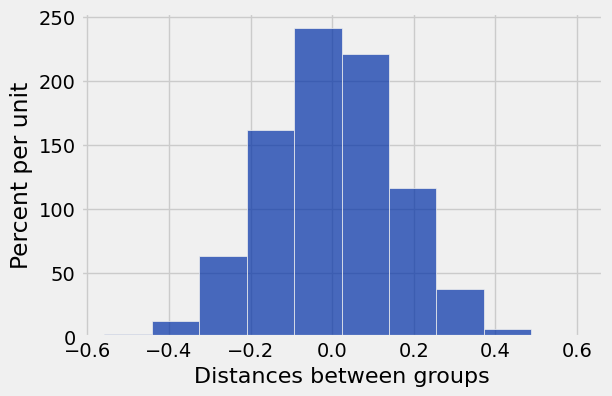

In [19]:
col_name = 'Distances between groups'
Table().with_column(col_name, simulated_diffs).hist(col_name)

In [20]:
# p-value
sum(simulated_diffs >= observed_diff)/len(simulated_diffs)

0.0071000000000000004

# Difference of Two Proportions Using a Z-Test

In this example, we compare the success rates of two groups using a traditional hypothesis test for the difference between two population proportions.

## Step 1: State the Hypotheses

We want to determine whether the two population proportions are different.

$$
H_0: p_1 = p_2
$$

$$
H_a: p_1 \ne p_2
$$

This is a **two-tailed test**.

---

## Step 2: Sample Information

From the data:

| Group | Successes | Sample Size |
|---------|---------:|---------:|
| Group 1 | 2 | 16 |
| Group 2 | 9 | 15 |

Sample proportions:

$$
\hat p_1 = \frac{2}{16}=0.125
$$

$$
\hat p_2 = \frac{9}{15}=0.600
$$

Observed difference:

$$
\hat p_1-\hat p_2
=0.125-0.600
=-0.475
$$

---

## Step 3: Compute the Pooled Proportion

Under the null hypothesis, we assume both groups come from the same population proportion.

The pooled estimate is

$$
\bar p
=
\frac{x_1+x_2}{n_1+n_2}
=
\frac{2+9}{16+15}
=
\frac{11}{31}
\approx 0.355
$$

and

$$
\bar q
=
1-\bar p
=
0.645
$$

---

## Step 4: Compute the Test Statistic

The standard error under the null hypothesis is

$$
SE
=
\sqrt{
\bar p \bar q
\left(
\frac1{n_1}
+
\frac1{n_2}
\right)
}
$$

Substituting the values:

$$
SE
=
\sqrt{
(0.355)(0.645)
\left(
\frac1{16}
+
\frac1{15}
\right)
}
$$

The z statistic is

$$
z
=
\frac{
(\hat p_1-\hat p_2)-0
}
{
SE
}
$$

$$
z
=
-2.762
$$

---

## Step 5: Compute the P-value

Since this is a two-tailed test,

$$
P\text{-value}
=
2P(Z<-2.762)
$$

Using the standard normal distribution,

$$
P(Z<-2.762)
=
0.00287
$$

Therefore,

$$
P\text{-value}
=
2(0.00287)
=
0.00574
$$

---

## Step 6: Conclusion

Because

$$
P\text{-value}
=
0.00574
<
0.05
$$
Assuming $$\alpha = 0.05$$

we reject the null hypothesis.

### Interpretation

There is strong statistical evidence that the two population proportions are different.

The observed difference of

$$
0.125-0.600=-0.475
$$

is unlikely to have occurred by random chance alone if the two population proportions were truly equal.

---

## Connection to Data 8 A/B Testing

In Data 8, we perform a permutation (shuffle) test:

1. Assume the treatment has no effect.
2. Randomly shuffle the labels many times.
3. Compute the difference in proportions for each shuffle.
4. Estimate the P-value as the fraction of shuffled differences that are at least as extreme as the observed difference.

For this example:

| Method | P-value |
|----------|---------:|
| Two-Proportion Z-Test | 0.0057 |
| Data 8 Simulation (A/B Test) | 0.0071 |
| Published Study | 0.0090 |

The three values are very close.

### Key Insight

Traditional statistics computes the P-value using a theoretical Normal distribution, while Data 8 estimates the same P-value empirically through simulation.

When sample sizes are sufficiently large, the two approaches often lead to very similar conclusions.